In [76]:
# !pip install adjustText

In [84]:
import os
import numpy as np
import random
import pandas as pd
import pickle

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

from adjustText import adjust_text

import re
import textwrap

In [2]:
seed = 316
random.seed(seed)
np.random.seed(seed)


In [171]:
def clean_title(title):
    # remove anything like (1997), (II), etc.
    title = re.sub(r"\s*\([^)]*\)\s*", "", title)

    # move ", The" to the front
    if title.endswith(", The"):
        title = "The " + title[:-5]   # remove ", The" and prepend

    # wrap long titles
    title = textwrap.fill(title, width=12)

    return title

In [6]:
pmf_raw_data = pd.read_csv("../data/movielens_1M_pmf_raw_data.csv")
print(f"Loaded {len(pmf_raw_data)} ratings")

Loaded 1000209 ratings


In [7]:
user2idx = pickle.load(open("../data/user2idx.pkl", "rb"))
movie2idx = pickle.load(open("../data/movie2idx.pkl", "rb"))

In [8]:
user_embeddings = np.load('../data/user_embeddings.npy')
movie_embeddings = np.load('../data/movie_embeddings.npy')

print(f"User embeddings: {user_embeddings.shape}") # should be (6040, 100)
print(f"Movie embeddings: {movie_embeddings.shape}") # should be (3706, 100)

User embeddings: (6040, 100)
Movie embeddings: (3706, 100)


In [14]:
movie_idx_to_title = pickle.load(open("../data/movie_index_to_title.pkl", "rb"))

In [11]:
pmf_raw_data.head(10)

,user_id,movie_id,rating,timestamp,user_idx,movie_idx
0,1,1193,5.0,978300760,0,1104
1,1,661,3.0,978302109,0,639
2,1,914,3.0,978301968,0,853
3,1,3408,4.0,978300275,0,3177
4,1,2355,5.0,978824291,0,2162
5,1,1197,3.0,978302268,0,1107
6,1,1287,5.0,978302039,0,1195
7,1,2804,5.0,978300719,0,2599
8,1,594,4.0,978302268,0,580
9,1,919,4.0,978301368,0,858


In [17]:
# Using embeddings_raw which you just loaded
print("Reduct Dimensions to 2D: Running t-SNE (this may take a minute)...")
tsne = TSNE(n_components=2, perplexity=30, random_state=seed)
z_2d = tsne.fit_transform(movie_embeddings) 
print("Done! 'z_2d' is now ready.")

Reduct Dimensions to 2D: Running t-SNE (this may take a minute)...
Done! 'z_2d' is now ready.


In [22]:
labels = list(movie_idx_to_title.values())
print(len(labels))

In [27]:
indices = list(movie_idx_to_title.keys())
print(len(indices))

3706
3706


In [28]:
# Create the colors and shuffle them ONCE with a fixed seed
colors = sns.color_palette("husl", len(labels))
np.random.seed(seed)
np.random.shuffle(colors)

# Map each Ground Truth ID to a specific, permanent color
gt_color_dict = dict(zip(labels, colors))

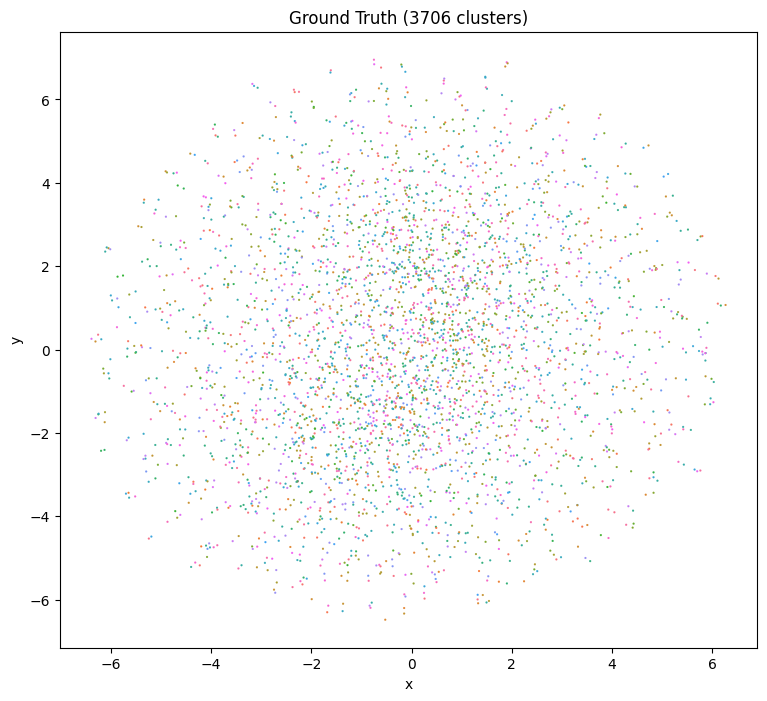

In [35]:
# Visualize the Ground Truth
plt.figure(figsize=(9, 8))

# We use the 'label' column from your dataframe 'df' for the ground truth colors
# Using legend=False because 503 labels would overwhelm the plot
sns.scatterplot(
    x=z_2d[:, 0], 
    y=z_2d[:, 1], 
    hue=labels, 
    palette=gt_color_dict, 
    s=2,
    alpha=1.0,
    edgecolor=None,
    legend=False,
)

plt.title(f'Ground Truth ({len(labels)} clusters)')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

# Only plot a few movies

In [96]:
top_movies = (
    pmf_raw_data[pmf_raw_data['rating'] == 5]   # filter 5-star ratings
    .groupby('movie_idx')                       # group by movie
    .size()                                     # count occurrences
    .sort_values(ascending=False)               # sort descending
)

# print(type(top_movies))
# A series that contains Movie Index & The Number of how many 5-star ratings that movie got

In [97]:
num_samples = 30
# print(top_movies.head(num_samples))

top_movies_named = []
for idx, count in top_movies.items():
    title = movie_idx_to_title.get(idx, "Unknown")
    top_movies_named.append((idx, title, count))

for idx, title, count in top_movies_named[:num_samples]:
    # Print INDEX, TITLE, Number of 5 star ratings that movie got
    print(f"{idx}. {title} | {count}")

2651. American Beauty (1999) | 1963
253. Star Wars: Episode IV - A New Hope (1977) | 1826
1108. Raiders of the Lost Ark (1981) | 1500
1106. Star Wars: Episode V - The Empire Strikes Back (1980) | 1483
802. Godfather, The (1972) | 1475
513. Schindler's List (1993) | 1475
309. Shawshank Redemption, The (1994) | 1457
2374. Matrix, The (1999) | 1430
1848. Saving Private Ryan (1998) | 1405
2557. Sixth Sense, The (1999) | 1385
579. Silence of the Lambs, The (1991) | 1350
593. Fargo (1996) | 1278
106. Braveheart (1995) | 1206
287. Pulp Fiction (1994) | 1193
1107. Princess Bride, The (1987) | 1186
49. Usual Suspects, The (1995) | 1144
1120. Star Wars: Episode VI - Return of the Jedi (1983) | 1028
1485. L.A. Confidential (1997) | 1009
2785. Being John Malkovich (1999) | 1007
2203. Shakespeare in Love (1998) | 987
851. Casablanca (1942) | 984
346. Forrest Gump (1994) | 945
575. Terminator 2: Judgment Day (1991) | 942
1131. Godfather: Part II, The (1974) | 941
1104. One Flew Over the Cuckoo's Nes

In [98]:
print(type(top_movies_named))

print(top_movies_named[:5])

<class 'list'>
[(2651, 'American Beauty (1999)', 1963), (253, 'Star Wars: Episode IV - A New Hope (1977)', 1826), (1108, 'Raiders of the Lost Ark (1981)', 1500), (1106, 'Star Wars: Episode V - The Empire Strikes Back (1980)', 1483), (802, 'Godfather, The (1972)', 1475)]


In [99]:
# top_movies_named = top_movies_named[::2]

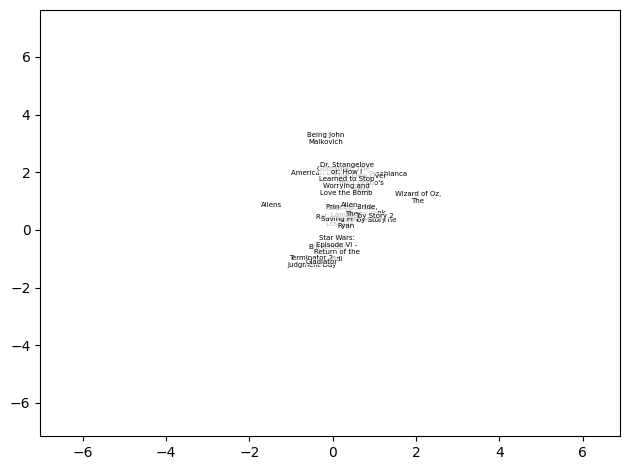

In [93]:
x_margin = (z_2d[:, 0].max() - z_2d[:, 0].min()) * 0.05
y_margin = (z_2d[:, 1].max() - z_2d[:, 1].min()) * 0.05

plt.xlim(z_2d[:, 0].min() - x_margin, z_2d[:, 0].max() + x_margin)
plt.ylim(z_2d[:, 1].min() - y_margin, z_2d[:, 1].max() + y_margin)

for idx, title, _ in top_movies_named[:20]:
    plt.text(
        z_2d[idx, 0],
        z_2d[idx, 1],
        clean_title(title),
        fontsize=5,
        ha='center',
        va='center',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=0.2),
        clip_on=False 
    )

plt.tight_layout()
plt.show()

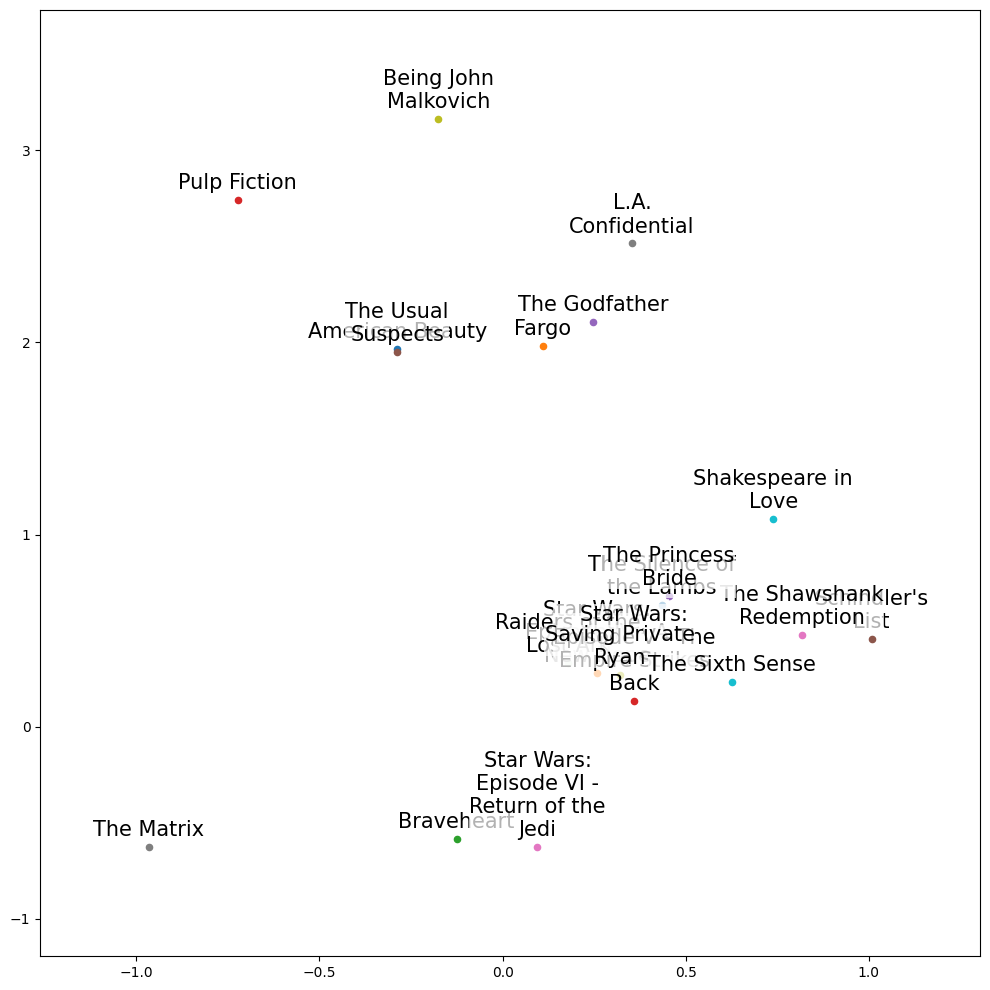

In [163]:
top_idxs = [(idx, title) for idx, title, _ in top_movies_named[:20]]
idxs = [idx for idx, _ in top_idxs]

# Zoom centers
cx = z_2d[idxs, 0].mean()
cy = z_2d[idxs, 1].mean()

# Compute zoom width
x_range = (z_2d[idxs, 0].max() - z_2d[idxs, 0].min())
y_range = (z_2d[idxs, 1].max() - z_2d[idxs, 1].min())

xmin = z_2d[idxs, 0].min()
xmax = z_2d[idxs, 0].max()

ymin = z_2d[idxs, 1].min()
ymax = z_2d[idxs, 1].max()

# zoom factor (<1 = zoom in)
zoom = 1.3

x_mid = (xmin + xmax) / 2
y_mid = (ymin + ymax) / 2

x_half = (xmax - xmin) * zoom / 2
y_half = (ymax - ymin) * zoom / 2


plt.figure(figsize=(10, 10))
plt.xlim(x_mid - x_half, x_mid + x_half)
plt.ylim(y_mid - y_half, y_mid + y_half)

for idx, title in top_idxs[:30]:
    x,y = z_2d[idx]
    plt.scatter(x, y, s=20)
    
    plt.annotate(
        text=clean_title(title),
        xy=(x,y),
        fontsize=15,
        ha='center',
        va='bottom',
        xytext=(0,5),
        textcoords='offset points',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=0.2),
        clip_on=True 
    )

plt.tight_layout()
plt.show()

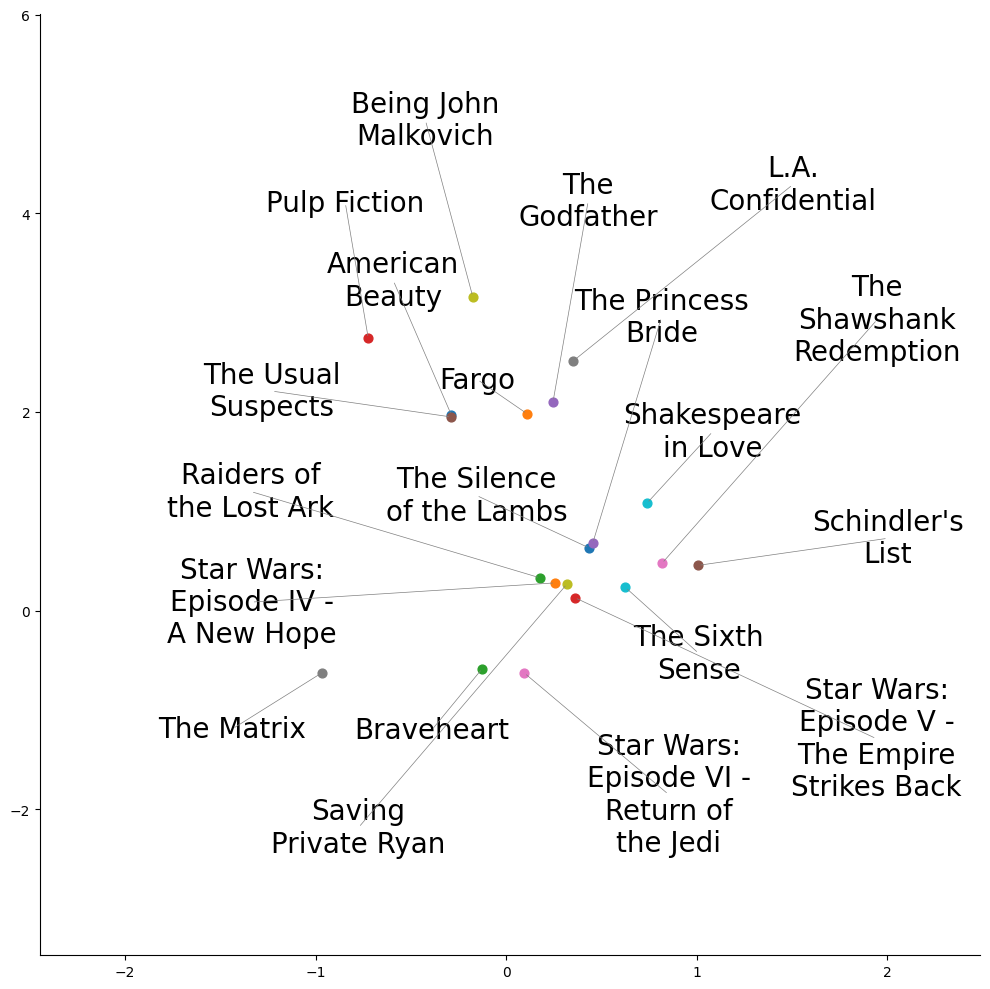

In [213]:
top_idxs = [(idx, title) for idx, title, _ in top_movies_named[:20]]
idxs = [idx for idx, _ in top_idxs]

# Zoom centers
cx = z_2d[idxs, 0].mean()
cy = z_2d[idxs, 1].mean()

# Compute zoom width
x_range = (z_2d[idxs, 0].max() - z_2d[idxs, 0].min())
y_range = (z_2d[idxs, 1].max() - z_2d[idxs, 1].min())

xmin = z_2d[idxs, 0].min()
xmax = z_2d[idxs, 0].max()

ymin = z_2d[idxs, 1].min()
ymax = z_2d[idxs, 1].max()

# zoom factor (<1 = zoom in)
zoom = 2.5

x_mid = (xmin + xmax) / 2
y_mid = (ymin + ymax) / 2

x_half = (xmax - xmin) * zoom / 2
y_half = (ymax - ymin) * zoom / 2


fig, ax = plt.subplots(figsize=(10, 10))

plt.xlim(x_mid - x_half, x_mid + x_half)
plt.ylim(y_mid - y_half, y_mid + y_half)

texts = []
for idx, title in top_idxs[:30]:
    x,y = z_2d[idx]
    plt.scatter(x, y, s=40)
    
    # text = plt.annotate(
    #     text=clean_title(title),
    #     xy=(x,y),
    #     fontsize=15,
    #     ha='center',
    #     va='bottom',
    #     xytext=(0,5),
    #     textcoords='offset points',
    #     bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=0.2),
    #     clip_on=True 
    # )
    text = plt.text(
        x,
        y,
        clean_title(title),
        fontsize=20,
        ha='center',
        va='bottom',
        bbox=dict(facecolor='white', alpha=0.0, edgecolor='none', pad=0.2),
    )
    
    texts.append(text)

et = 1
ep = 3
ft = 2.5
fp = 1.5

adjust_text(
    texts,
    ax=ax,
    expand_text=(et, et),
    expand_points=(ep, ep),
    force_text=(ft, ft),
    force_points=(fp, fp),
    arrowprops=dict(arrowstyle='-', color='gray', lw=0.5)
)

ax.spines[['right', 'top']].set_visible(False)
plt.tight_layout()
plt.show()

In [105]:
x_margin = (z_2d[:, 0].max() - z_2d[:, 0].min()) * 0.05
y_margin = (z_2d[:, 1].max() - z_2d[:, 1].min()) * 0.05

plt.xlim(z_2d[:, 0].min() - x_margin, z_2d[:, 0].max() + x_margin)
plt.ylim(z_2d[:, 1].min() - y_margin, z_2d[:, 1].max() + y_margin)

for idx, title, _ in top_movies_named[:20]:
    plt.text(
        z_2d[idx, 0],
        z_2d[idx, 1],
        clean_title(title),
        fontsize=5,
        ha='center',
        va='center',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=0.2),
        clip_on=False 
    )

plt.tight_layout()
plt.show()

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


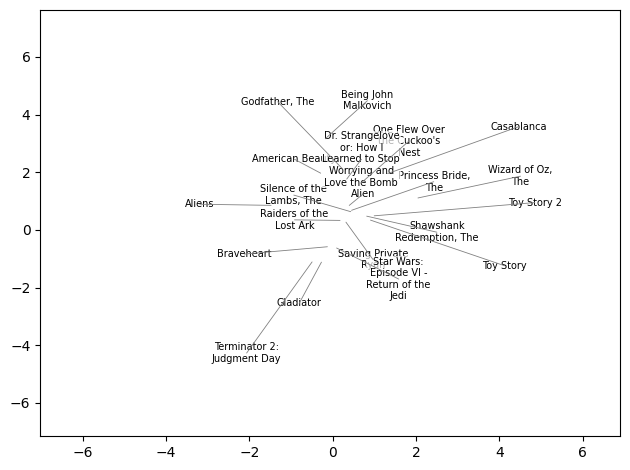

In [95]:
fig, ax = plt.subplots()

ax.set_xlim(z_2d[:, 0].min() - x_margin, z_2d[:, 0].max() + x_margin)
ax.set_ylim(z_2d[:, 1].min() - y_margin, z_2d[:, 1].max() + y_margin)

texts = []

for idx, title, _ in top_movies_named[:20]:
    texts.append(
        ax.text(
            z_2d[idx, 0],
            z_2d[idx, 1],
            clean_title(title),
            fontsize=7,
            ha='center',
            va='center',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=0.2),
        )
    )

# adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))
adjust_text(
    texts,
    ax=ax,
    expand_text=(3, 3),
    expand_points=(3, 3),
    force_text=(2, 2),
    force_points=(1, 1),
    only_move={'text': 'xy'},
    arrowprops=dict(arrowstyle='-', color='gray', lw=0.6, shrinkA=0, shrinkB=0)
)

plt.tight_layout()
plt.show()